# YOLO v1 — You Only Look Once: Unified, Real-Time Object Detection

**Aprendizaje Profundo — UNSAM | Full Demo**

**Paper:** Redmon, J., Divvala, S., Girshick, R., & Farhadi, A. (2016). *You Only Look Once: Unified, Real-Time Object Detection.* CVPR 2016.

This notebook demonstrates the core ideas of YOLO v1:

1. The image is divided into an S×S grid.
2. Each grid cell predicts B bounding boxes + confidence, and C class probabilities.
3. A single forward pass produces all detections (hence "You Only Look Once").
4. Non-Maximum Suppression (NMS) filters overlapping boxes.
5. A multi-part loss function balances localisation, confidence, and class errors.

We train a *simplified* YOLO v1 on a **synthetic dataset** of coloured shapes so that the full pipeline can run in minutes on a CPU / single GPU.

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageDraw
import random
import time

# ── Reproducibility ────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 1. YOLO v1 — Key Concepts

### 1.1 Grid Division
The image is divided into an **S×S grid** (the paper uses S=7). The cell that contains the **centre** of an object is responsible for detecting that object.

### 1.2 Predictions Per Cell
Each cell predicts:
- **B bounding boxes**, each with 5 values: `(x, y, w, h, confidence)`
  - `x, y` : centre offset relative to the cell (0–1)
  - `w, h` : width/height relative to the full image (0–1)
  - `confidence = P(Object) × IoU(pred, truth)`
- **C class probabilities** (conditional on object present)

### 1.3 Output Tensor
Shape: **S × S × (B\*5 + C)**  
Paper: 7 × 7 × (2\*5 + 20) = 7 × 7 × 30

### 1.4 Loss Function (multi-part)
$$L = \lambda_{\text{coord}} \cdot L_{xy} + \lambda_{\text{coord}} \cdot L_{wh} + L_{\text{conf\_obj}} + \lambda_{\text{noobj}} \cdot L_{\text{conf\_noobj}} + L_{\text{class}}$$

- $\sqrt{w}$, $\sqrt{h}$ are used to penalise small-box errors more.

### 1.5 Non-Maximum Suppression (NMS)
After prediction, overlapping boxes for the same class are filtered by keeping the highest-confidence one.

---
## 2. Synthetic Dataset

We generate 128×128 images with simple coloured shapes (circles, rectangles, triangles) to keep training fast and illustrative.

In [20]:
CLASSES = ["circle", "rectangle", "triangle"]
NUM_CLASSES = len(CLASSES)
IMG_SIZE = 128

# YOLO hyper-parameters (simplified)
S = 7          # Grid size
B = 2          # Bounding boxes per cell
LAMBDA_COORD = 5.0
LAMBDA_NOOBJ = 0.5

In [21]:
def random_color():
    """Return a random bright RGB colour."""
    return tuple(random.randint(100, 255) for _ in range(3))


def generate_sample(img_size=IMG_SIZE, max_objects=3):
    """
    Generate one synthetic image with random shapes and their bounding boxes.

    Returns:
        image : PIL.Image (RGB, img_size × img_size)
        boxes : list of [class_id, x_center, y_center, width, height]
                all normalised to [0, 1]
    """
    img = Image.new("RGB", (img_size, img_size), color=(30, 30, 30))
    draw = ImageDraw.Draw(img)
    boxes = []

    n_objects = random.randint(1, max_objects)

    for _ in range(n_objects):
        cls = random.randint(0, NUM_CLASSES - 1)
        color = random_color()

        # Random size and position
        obj_w = random.randint(15, 45)
        obj_h = random.randint(15, 45)
        x1 = random.randint(0, img_size - obj_w)
        y1 = random.randint(0, img_size - obj_h)
        x2 = x1 + obj_w
        y2 = y1 + obj_h

        if cls == 0:  # circle
            draw.ellipse([x1, y1, x2, y2], fill=color)
        elif cls == 1:  # rectangle
            draw.rectangle([x1, y1, x2, y2], fill=color)
        elif cls == 2:  # triangle
            cx = (x1 + x2) / 2
            draw.polygon([(cx, y1), (x1, y2), (x2, y2)], fill=color)

        # Normalised bounding box
        xc = ((x1 + x2) / 2) / img_size
        yc = ((y1 + y2) / 2) / img_size
        w = obj_w / img_size
        h = obj_h / img_size
        boxes.append([cls, xc, yc, w, h])

    return img, boxes

In [22]:
class SyntheticDetectionDataset(Dataset):
    """Generates a synthetic dataset on the fly."""

    def __init__(self, num_samples=1000, img_size=IMG_SIZE, S=S, B=B,
                 num_classes=NUM_CLASSES, max_objects=3):
        self.num_samples = num_samples
        self.img_size = img_size
        self.S = S
        self.B = B
        self.C = num_classes
        self.max_objects = max_objects

        # Pre-generate all samples for consistency
        self.data = [generate_sample(img_size, max_objects)
                     for _ in range(num_samples)]

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        img, boxes = self.data[idx]

        # Image → tensor [3, H, W] normalised to [0, 1]
        img_tensor = torch.tensor(
            np.array(img), dtype=torch.float32
        ).permute(2, 0, 1) / 255.0

        # Encode boxes into YOLO target tensor: S × S × (5*B + C)
        target = self.encode_target(boxes)

        return img_tensor, target

    def encode_target(self, boxes):
        """
        Convert list of [class_id, xc, yc, w, h] into the YOLO ground-truth
        tensor of shape (S, S, 5*B + C).

        For each object, the grid cell containing its centre is responsible.
        We store: [x_offset, y_offset, w, h, 1(confidence), ..., class_onehot]
        The same box is duplicated across B slots (both predict the same truth).
        """
        target = torch.zeros(self.S, self.S, 5 * self.B + self.C)

        for box in boxes:
            cls_id, xc, yc, w, h = box

            # Which grid cell?
            grid_x = int(xc * self.S)
            grid_y = int(yc * self.S)
            grid_x = min(grid_x, self.S - 1)
            grid_y = min(grid_y, self.S - 1)

            # Offset within the cell (0-1)
            x_offset = xc * self.S - grid_x
            y_offset = yc * self.S - grid_y

            # If this cell is not yet assigned (first object wins)
            if target[grid_y, grid_x, 4] == 0:
                # Fill B identical box slots
                for b in range(self.B):
                    base = b * 5
                    target[grid_y, grid_x, base + 0] = x_offset
                    target[grid_y, grid_x, base + 1] = y_offset
                    target[grid_y, grid_x, base + 2] = w
                    target[grid_y, grid_x, base + 3] = h
                    target[grid_y, grid_x, base + 4] = 1.0  # confidence

                # One-hot class
                target[grid_y, grid_x, 5 * self.B + cls_id] = 1.0

        return target

---
## 3. Visualise the Dataset

In [23]:
def visualise_samples(dataset, n=6):
    """Show sample images with their ground-truth bounding boxes."""
    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    axes = axes.ravel()

    cmap = ["cyan", "lime", "orange"]

    for i in range(n):
        img_t, target = dataset[i]
        img_np = img_t.permute(1, 2, 0).numpy()

        axes[i].imshow(img_np)
        axes[i].set_title(f"Sample {i}", fontsize=12)
        axes[i].axis("off")

        # Decode target back to boxes for drawing
        for gy in range(S):
            for gx in range(S):
                if target[gy, gx, 4] > 0.5:
                    x_off = target[gy, gx, 0].item()
                    y_off = target[gy, gx, 1].item()
                    w = target[gy, gx, 2].item()
                    h = target[gy, gx, 3].item()

                    xc = (gx + x_off) / S * IMG_SIZE
                    yc = (gy + y_off) / S * IMG_SIZE
                    bw = w * IMG_SIZE
                    bh = h * IMG_SIZE

                    cls_id = target[gy, gx, 5 * B:].argmax().item()
                    color = cmap[cls_id]

                    rect = patches.Rectangle(
                        (xc - bw / 2, yc - bh / 2), bw, bh,
                        linewidth=2, edgecolor=color, facecolor="none"
                    )
                    axes[i].add_patch(rect)
                    axes[i].text(
                        xc - bw / 2, yc - bh / 2 - 3,
                        CLASSES[cls_id], color=color,
                        fontsize=9, weight="bold",
                        bbox=dict(facecolor="black", alpha=0.5, pad=1)
                    )

    plt.suptitle("Synthetic Dataset — Ground Truth", fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()

Generating synthetic dataset...
Train: 2000 samples  |  Val: 300 samples
Target tensor shape per image: (7, 7, 13)


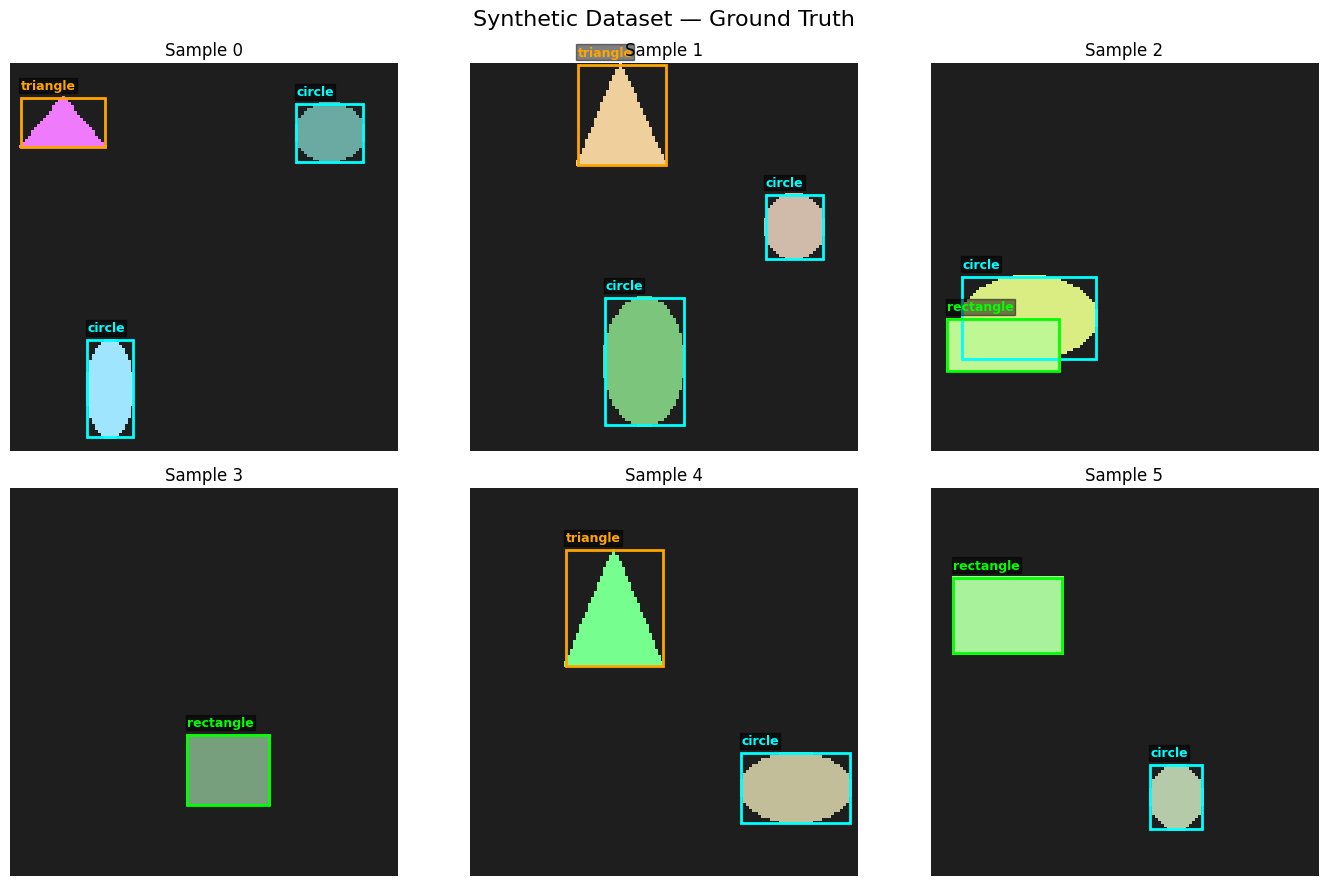


Dataset details:
  Image tensor shape: torch.Size([3, 128, 128])
  Target tensor shape: torch.Size([7, 7, 13])

Sample target grid (first sample):
  Shape: torch.Size([7, 7, 13])

Full target tensor for first sample:
  Cell (1, 0): tensor([0.9297, 0.0391, 0.2188, 0.1250, 1.0000, 0.9297, 0.0391, 0.2188, 0.1250,
        1.0000, 0.0000, 0.0000, 1.0000])
  Cell (1, 5): tensor([0.7422, 0.2305, 0.1719, 0.1484, 1.0000, 0.7422, 0.2305, 0.1719, 0.1484,
        1.0000, 1.0000, 0.0000, 0.0000])
  Cell (5, 1): tensor([0.7773, 0.8516, 0.1172, 0.2500, 1.0000, 0.7773, 0.8516, 0.1172, 0.2500,
        1.0000, 1.0000, 0.0000, 0.0000])

Checking target encoding:
  Sample 0: 3 object(s) encoded
  Sample 1: 3 object(s) encoded
  Sample 2: 2 object(s) encoded


In [24]:
# Create datasets
print("Generating synthetic dataset...")
train_dataset = SyntheticDetectionDataset(num_samples=2000, max_objects=3)
val_dataset = SyntheticDetectionDataset(num_samples=300, max_objects=3)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Train: {len(train_dataset)} samples  |  Val: {len(val_dataset)} samples")
print(f"Target tensor shape per image: ({S}, {S}, {5*B + NUM_CLASSES})")

visualise_samples(train_dataset, n=6)

# Print dataset details
print(f"\nDataset details:")
print(f"  Image tensor shape: {train_dataset[0][0].shape}")
print(f"  Target tensor shape: {train_dataset[0][1].shape}")

# Show the full target grid for the first sample
print(f"\nSample target grid (first sample):")
print(f"  Shape: {train_dataset[0][1].shape}")
print(f"\nFull target tensor for first sample:")
for gy in range(S):
    for gx in range(S):
        cell_values = train_dataset[0][1][gy, gx, :]
        if cell_values[4] > 0.5:  # If object present
            print(f"  Cell ({gy}, {gx}): {cell_values}")

print(f"\nChecking target encoding:")
for i in range(3):
    img_t, target_t = train_dataset[i]
    n_objects = (target_t[..., 4] > 0.5).sum().item()
    print(f"  Sample {i}: {n_objects} object(s) encoded")

---
## 4. YOLO v1 Model (Simplified)

The original paper uses a backbone inspired by **GoogLeNet** (24 conv layers) followed by 2 fully connected layers. Here we use a much smaller CNN that captures the same ideas but trains fast on our 128×128 toy data.

**Output:** `(batch, S, S, 5*B + C)` = `(batch, 7, 7, 13)`

In [25]:
class YOLOv1(nn.Module):
    """
    Simplified YOLO v1 architecture.
    Output: (batch, S, S, 5*B + C) = (batch, 7, 7, 13)
    """

    def __init__(self, S=7, B=2, C=3):
        super().__init__()
        self.S = S
        self.B = B
        self.C = C

        # ── Feature extractor ──
        self.backbone = nn.Sequential(
            # Block 1: 128→64
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),

            # Block 2: 64→32
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),

            # Block 3: 32→16
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),

            # Block 4: 16→8
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),

            # Block 5: 8→4
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),
            # Output: (batch, 512, 4, 4)
        )

        # ── Detection head ──
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 1024),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.5),
            nn.Linear(1024, S * S * (5 * B + C)),
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        # Reshape to (batch, S, S, 5*B + C)
        x = x.view(-1, self.S, self.S, 5 * self.B + self.C)
        return x

In [26]:
# Instantiate and inspect
model = YOLOv1(S=S, B=B, C=NUM_CLASSES).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"YOLO v1 model — Parameters: {n_params:,}")

# Quick forward pass test
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
out = model(dummy)
print(f"Input: {dummy.shape}  →  Output: {out.shape}")
print(f"Expected output: (2, {S}, {S}, {5*B + NUM_CLASSES})")

YOLO v1 model — Parameters: 10,613,117
Input: torch.Size([2, 3, 128, 128])  →  Output: torch.Size([2, 7, 7, 13])
Expected output: (2, 7, 7, 13)


---
## 5. YOLO v1 Loss Function

The multi-part loss from the paper:

$$L = \lambda_{\text{coord}} \sum_{\text{obj}} \left[(x - \hat{x})^2 + (y - \hat{y})^2\right]
+ \lambda_{\text{coord}} \sum_{\text{obj}} \left[(\sqrt{w} - \sqrt{\hat{w}})^2 + (\sqrt{h} - \sqrt{\hat{h}})^2\right]
+ \sum_{\text{obj}} (C - \hat{C})^2
+ \lambda_{\text{noobj}} \sum_{\text{noobj}} (C - \hat{C})^2
+ \sum_{\text{obj}} \sum_c (p_c - \hat{p}_c)^2$$

The sums are only over the *responsible* bounding box (the one with highest IoU with ground truth).

In [27]:
class YOLOv1Loss(nn.Module):
    """
    Multi-part loss function from the YOLO v1 paper.
    """

    def __init__(self, S=7, B=2, C=3, lambda_coord=5.0, lambda_noobj=0.5):
        super().__init__()
        self.S = S
        self.B = B
        self.C = C
        self.lambda_coord = lambda_coord
        self.lambda_noobj = lambda_noobj

    def forward(self, predictions, targets):
        """
        predictions : (batch, S, S, 5*B + C)
        targets     : (batch, S, S, 5*B + C)
        """
        batch_size = predictions.shape[0]

        # ── Masks ──
        obj_mask = targets[..., 4] > 0.5      # (batch, S, S)
        noobj_mask = ~obj_mask

        # === 1. COORDINATE LOSS ===
        pred_xy = predictions[..., 0:2]
        pred_wh = predictions[..., 2:4]
        targ_xy = targets[..., 0:2]
        targ_wh = targets[..., 2:4]

        obj_mask_box = obj_mask.unsqueeze(-1)

        xy_loss = torch.sum(obj_mask_box * (pred_xy - targ_xy) ** 2)

        # Square-root trick for width/height
        pred_wh_safe = torch.sign(pred_wh) * torch.sqrt(torch.abs(pred_wh) + 1e-8)
        targ_wh_sqrt = torch.sqrt(targ_wh + 1e-8)
        wh_loss = torch.sum(obj_mask_box * (pred_wh_safe - targ_wh_sqrt) ** 2)

        coord_loss = self.lambda_coord * (xy_loss + wh_loss)

        # === 2. CONFIDENCE LOSS ===
        pred_conf0 = predictions[..., 4]
        targ_conf = targets[..., 4]
        pred_conf1 = predictions[..., 9]

        conf_obj_loss = (
            torch.sum(obj_mask * (pred_conf0 - targ_conf) ** 2) +
            torch.sum(obj_mask * (pred_conf1 - targ_conf) ** 2)
        )

        conf_noobj_loss = self.lambda_noobj * (
            torch.sum(noobj_mask * (pred_conf0 - 0) ** 2) +
            torch.sum(noobj_mask * (pred_conf1 - 0) ** 2)
        )

        # === 3. CLASS LOSS ===
        pred_class = predictions[..., 5 * self.B:]
        targ_class = targets[..., 5 * self.B:]

        class_loss = torch.sum(
            obj_mask.unsqueeze(-1) * (pred_class - targ_class) ** 2
        )

        # === TOTAL ===
        total_loss = (coord_loss + conf_obj_loss + conf_noobj_loss +
                      class_loss) / batch_size

        return total_loss

---
## 6. IoU & Non-Maximum Suppression (NMS)

In [28]:
def compute_iou(box1, box2):
    """
    Compute Intersection over Union between two boxes.
    Each box: [x_center, y_center, width, height] (normalised).
    """
    b1_x1 = box1[0] - box1[2] / 2
    b1_y1 = box1[1] - box1[3] / 2
    b1_x2 = box1[0] + box1[2] / 2
    b1_y2 = box1[1] + box1[3] / 2

    b2_x1 = box2[0] - box2[2] / 2
    b2_y1 = box2[1] - box2[3] / 2
    b2_x2 = box2[0] + box2[2] / 2
    b2_y2 = box2[1] + box2[3] / 2

    inter_x1 = max(b1_x1, b2_x1)
    inter_y1 = max(b1_y1, b2_y1)
    inter_x2 = min(b1_x2, b2_x2)
    inter_y2 = min(b1_y2, b2_y2)

    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    union_area = (box1[2] * box1[3] + box2[2] * box2[3] - inter_area)

    return inter_area / (union_area + 1e-8)


def decode_predictions(output, S=7, B=2, C=3, conf_threshold=0.3):
    """
    Decode the YOLO output tensor (S, S, 5*B + C) into a list of detections.
    Returns: list of [class_id, confidence, x_c, y_c, w, h]
    """
    detections = []

    for gy in range(S):
        for gx in range(S):
            cell = output[gy, gx]
            class_probs = cell[5 * B:]
            class_id = class_probs.argmax().item()
            class_prob = class_probs[class_id].item()

            for b in range(B):
                base = b * 5
                x_off = cell[base + 0].item()
                y_off = cell[base + 1].item()
                w = cell[base + 2].item()
                h = cell[base + 3].item()
                conf = cell[base + 4].item()

                score = class_prob * conf

                if score > conf_threshold:
                    xc = (gx + x_off) / S
                    yc = (gy + y_off) / S
                    detections.append([class_id, score, xc, yc, abs(w), abs(h)])

    return detections


def non_max_suppression(detections, iou_threshold=0.4):
    """
    Apply Non-Maximum Suppression per class.
    detections: list of [class_id, score, xc, yc, w, h]
    """
    if len(detections) == 0:
        return []

    detections = sorted(detections, key=lambda x: x[1], reverse=True)

    kept = []
    while detections:
        best = detections.pop(0)
        kept.append(best)

        remaining = []
        for det in detections:
            if det[0] == best[0]:
                iou = compute_iou(best[2:6], det[2:6])
                if iou < iou_threshold:
                    remaining.append(det)
            else:
                remaining.append(det)

        detections = remaining

    return kept

---
## 7. Training Loop

In [29]:
def train_yolo(model, train_loader, val_loader, device,
               epochs=40, lr=1e-3):
    """Full training loop with logging."""
    criterion = YOLOv1Loss(S=S, B=B, C=NUM_CLASSES)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

    history = {"train_loss": [], "val_loss": []}

    print(f"\n{'='*60}")
    print(f" Training YOLO v1  —  {epochs} epochs")
    print(f"{'='*60}")

    for epoch in range(1, epochs + 1):
        # ── Train ──
        model.train()
        train_loss = 0.0
        for images, targets in train_loader:
            images = images.to(device)
            targets = targets.to(device)

            preds = model(images)
            loss = criterion(preds, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

        train_loss /= len(train_loader.dataset)

        # ── Validate ──
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, targets in val_loader:
                images = images.to(device)
                targets = targets.to(device)
                preds = model(images)
                loss = criterion(preds, targets)
                val_loss += loss.item() * images.size(0)

        val_loss /= len(val_loader.dataset)

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if epoch % 5 == 0 or epoch == 1:
            lr_now = optimizer.param_groups[0]["lr"]
            print(f"  Epoch {epoch:3d}/{epochs}  |  "
                  f"Train Loss: {train_loss:.4f}  |  "
                  f"Val Loss: {val_loss:.4f}  |  LR: {lr_now:.6f}")

    print(f"{'='*60}\n")
    return history

In [30]:
# Train!
history = train_yolo(model, train_loader, val_loader, device, epochs=40, lr=1e-3)


 Training YOLO v1  —  40 epochs
  Epoch   1/40  |  Train Loss: 34.3479  |  Val Loss: 9.8164  |  LR: 0.001000
  Epoch   1/40  |  Train Loss: 34.3479  |  Val Loss: 9.8164  |  LR: 0.001000
  Epoch   5/40  |  Train Loss: 7.4965  |  Val Loss: 7.0124  |  LR: 0.001000
  Epoch   5/40  |  Train Loss: 7.4965  |  Val Loss: 7.0124  |  LR: 0.001000
  Epoch  10/40  |  Train Loss: 6.4339  |  Val Loss: 5.5846  |  LR: 0.001000
  Epoch  10/40  |  Train Loss: 6.4339  |  Val Loss: 5.5846  |  LR: 0.001000
  Epoch  15/40  |  Train Loss: 4.8722  |  Val Loss: 5.2412  |  LR: 0.000500
  Epoch  15/40  |  Train Loss: 4.8722  |  Val Loss: 5.2412  |  LR: 0.000500
  Epoch  20/40  |  Train Loss: 4.3704  |  Val Loss: 4.5394  |  LR: 0.000500
  Epoch  20/40  |  Train Loss: 4.3704  |  Val Loss: 4.5394  |  LR: 0.000500
  Epoch  25/40  |  Train Loss: 3.5585  |  Val Loss: 4.3802  |  LR: 0.000500
  Epoch  25/40  |  Train Loss: 3.5585  |  Val Loss: 4.3802  |  LR: 0.000500
  Epoch  30/40  |  Train Loss: 2.9832  |  Val Loss: 3

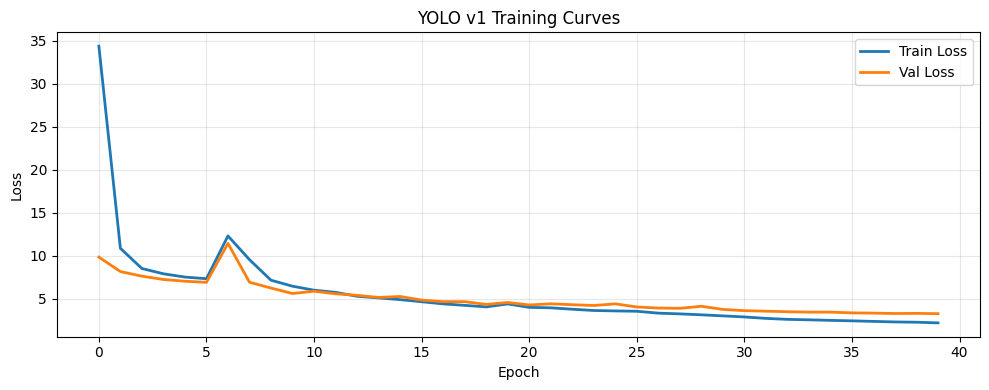

In [31]:
# Plot training curves
plt.figure(figsize=(10, 4))
plt.plot(history["train_loss"], label="Train Loss", linewidth=2)
plt.plot(history["val_loss"], label="Val Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("YOLO v1 Training Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. Visualise Grid & Predictions

Let's see how YOLO divides the image and which cells are responsible for each object.

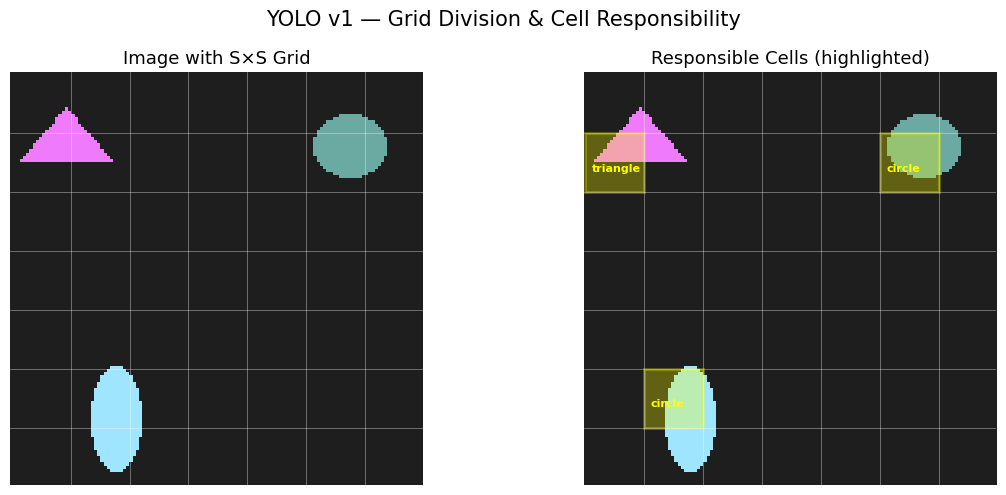

In [32]:
def visualise_grid_explanation(img_tensor, target, S=7):
    """Show how YOLO divides the image into a grid and which cells
    are responsible for each object."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    img_np = img_tensor.permute(1, 2, 0).numpy()
    cell_size = IMG_SIZE / S

    # Left: image with grid
    ax1.imshow(img_np)
    for i in range(1, S):
        ax1.axhline(i * cell_size, color="white", linewidth=0.5, alpha=0.5)
        ax1.axvline(i * cell_size, color="white", linewidth=0.5, alpha=0.5)
    ax1.set_title("Image with S×S Grid", fontsize=13)
    ax1.axis("off")

    # Right: which cells are responsible
    ax2.imshow(img_np)
    for i in range(1, S):
        ax2.axhline(i * cell_size, color="white", linewidth=0.5, alpha=0.5)
        ax2.axvline(i * cell_size, color="white", linewidth=0.5, alpha=0.5)

    for gy in range(S):
        for gx in range(S):
            if target[gy, gx, 4] > 0.5:
                rect = patches.Rectangle(
                    (gx * cell_size, gy * cell_size),
                    cell_size, cell_size,
                    linewidth=2, edgecolor="yellow",
                    facecolor="yellow", alpha=0.3
                )
                ax2.add_patch(rect)

                cls_id = target[gy, gx, 5 * B:].argmax().item()
                ax2.text(
                    gx * cell_size + 2, gy * cell_size + 12,
                    CLASSES[cls_id], color="yellow", fontsize=8,
                    weight="bold"
                )

    ax2.set_title("Responsible Cells (highlighted)", fontsize=13)
    ax2.axis("off")

    plt.suptitle("YOLO v1 — Grid Division & Cell Responsibility", fontsize=15)
    plt.tight_layout()
    plt.show()


# Show grid explanation for a sample
img_t, target_t = train_dataset[0]
visualise_grid_explanation(img_t, target_t)

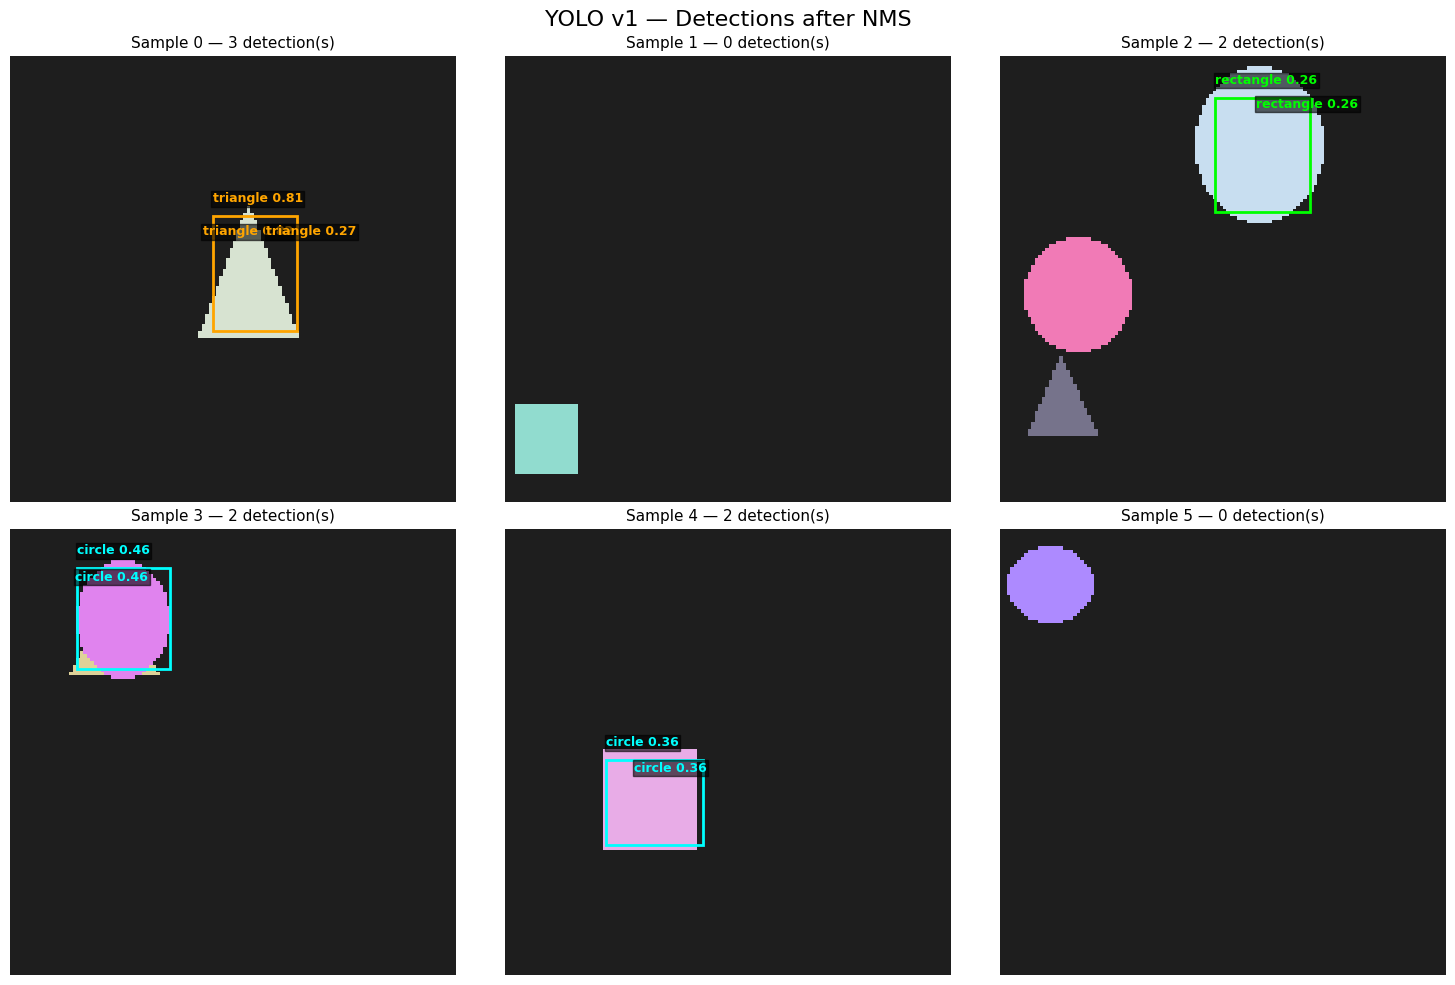

In [33]:
def visualise_detections(model, dataset, device, n=6,
                          conf_threshold=0.25, iou_threshold=0.4):
    """Run inference on samples and visualise detections."""
    model.eval()
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    cmap = ["cyan", "lime", "orange"]

    for i in range(n):
        img_t, target = dataset[i]
        img_np = img_t.permute(1, 2, 0).numpy()

        with torch.no_grad():
            pred = model(img_t.unsqueeze(0).to(device))
        pred = pred[0].cpu()

        detections = decode_predictions(
            pred, S=S, B=B, C=NUM_CLASSES, conf_threshold=conf_threshold
        )
        detections = non_max_suppression(detections, iou_threshold=iou_threshold)

        axes[i].imshow(img_np)
        axes[i].set_title(f"Sample {i} — {len(detections)} detection(s)",
                          fontsize=11)
        axes[i].axis("off")

        for det in detections:
            cls_id, score, xc, yc, w, h = det
            color = cmap[cls_id]

            px = xc * IMG_SIZE
            py = yc * IMG_SIZE
            pw = w * IMG_SIZE
            ph = h * IMG_SIZE

            rect = patches.Rectangle(
                (px - pw / 2, py - ph / 2), pw, ph,
                linewidth=2, edgecolor=color, facecolor="none"
            )
            axes[i].add_patch(rect)
            axes[i].text(
                px - pw / 2, py - ph / 2 - 4,
                f"{CLASSES[cls_id]} {score:.2f}",
                color=color, fontsize=9, weight="bold",
                bbox=dict(facecolor="black", alpha=0.6, pad=1)
            )

    plt.suptitle("YOLO v1 — Detections after NMS", fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()


# Visualise predictions
visualise_detections(model, val_dataset, device, n=6)

---
## 9. Ground Truth vs Predictions

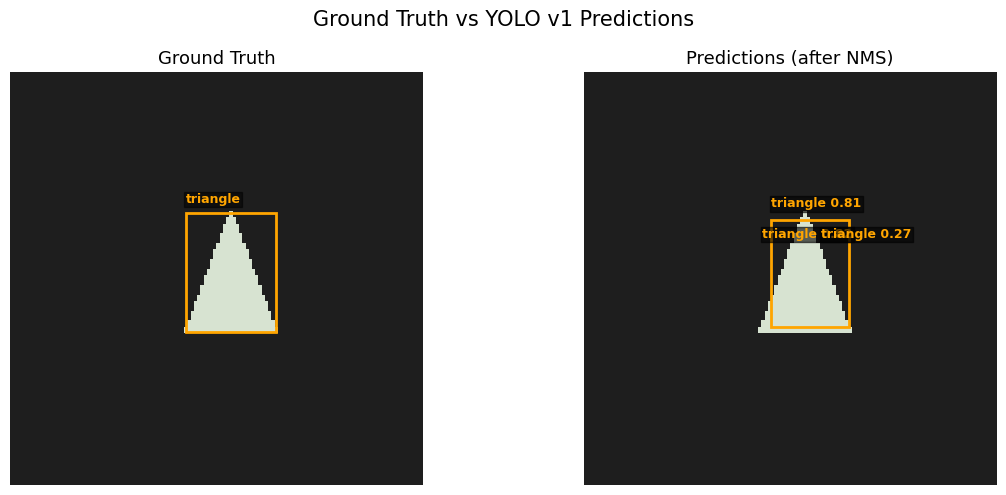

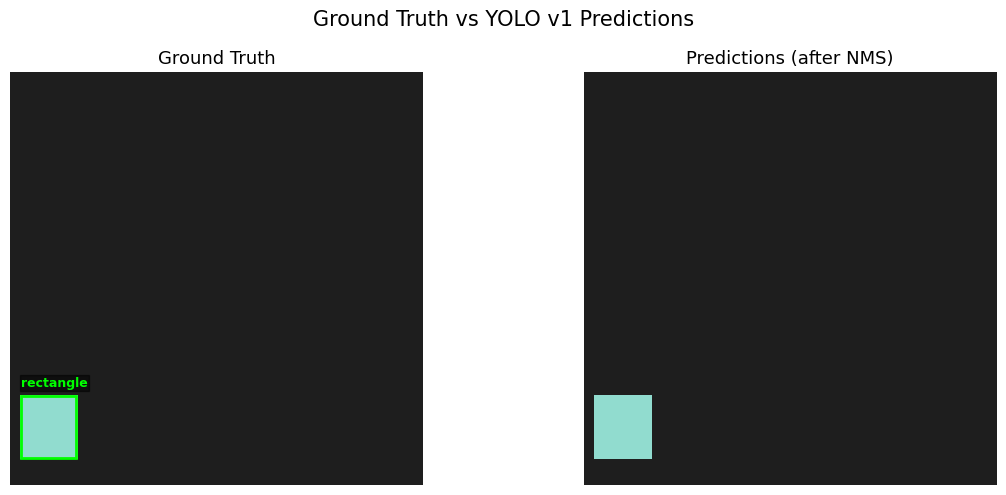

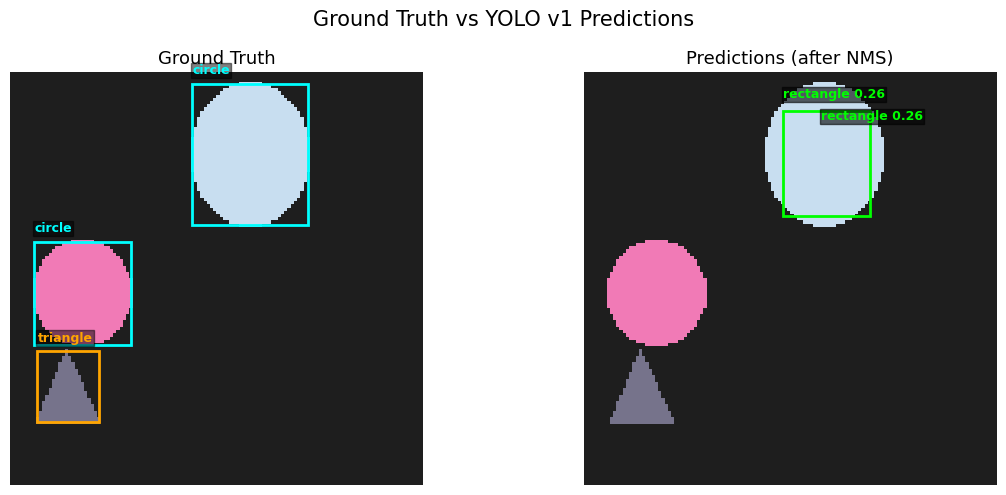

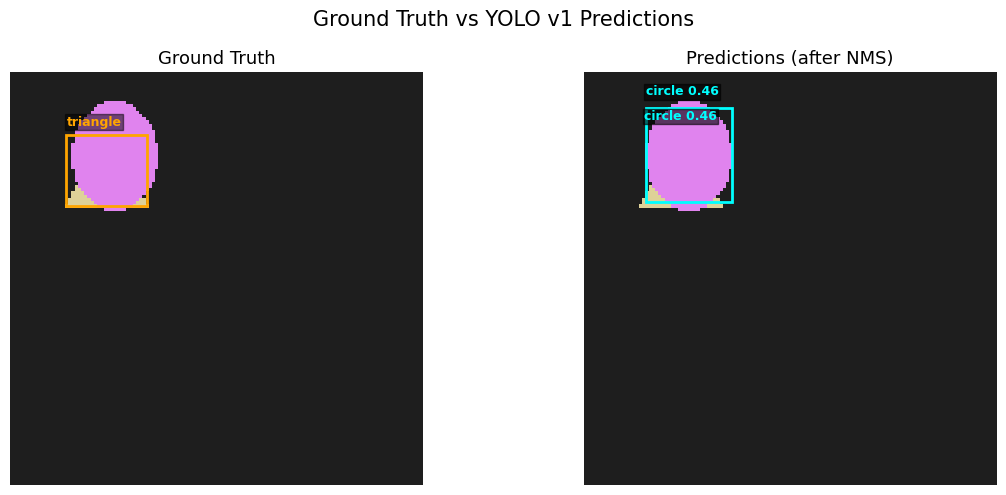

In [34]:
def compare_gt_vs_pred(model, dataset, device, idx=0,
                        conf_threshold=0.25, iou_threshold=0.4):
    """Side-by-side comparison of ground truth and predictions."""
    img_t, target = dataset[idx]
    img_np = img_t.permute(1, 2, 0).numpy()

    with torch.no_grad():
        pred = model(img_t.unsqueeze(0).to(device))[0].cpu()

    detections = decode_predictions(pred, S=S, B=B, C=NUM_CLASSES,
                                     conf_threshold=conf_threshold)
    detections = non_max_suppression(detections, iou_threshold=iou_threshold)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    cmap = ["cyan", "lime", "orange"]

    # Ground truth
    ax1.imshow(img_np)
    ax1.set_title("Ground Truth", fontsize=13)
    ax1.axis("off")
    for gy in range(S):
        for gx in range(S):
            if target[gy, gx, 4] > 0.5:
                x_off = target[gy, gx, 0].item()
                y_off = target[gy, gx, 1].item()
                w = target[gy, gx, 2].item()
                h = target[gy, gx, 3].item()
                xc = (gx + x_off) / S * IMG_SIZE
                yc = (gy + y_off) / S * IMG_SIZE
                bw = w * IMG_SIZE
                bh = h * IMG_SIZE
                cls_id = target[gy, gx, 5 * B:].argmax().item()
                rect = patches.Rectangle(
                    (xc - bw / 2, yc - bh / 2), bw, bh,
                    linewidth=2, edgecolor=cmap[cls_id], facecolor="none"
                )
                ax1.add_patch(rect)
                ax1.text(xc - bw / 2, yc - bh / 2 - 3,
                         CLASSES[cls_id], color=cmap[cls_id],
                         fontsize=9, weight="bold",
                         bbox=dict(facecolor="black", alpha=0.5, pad=1))

    # Predictions
    ax2.imshow(img_np)
    ax2.set_title("Predictions (after NMS)", fontsize=13)
    ax2.axis("off")
    for det in detections:
        cls_id, score, xc, yc, w, h = det
        color = cmap[cls_id]
        px, py = xc * IMG_SIZE, yc * IMG_SIZE
        pw, ph = w * IMG_SIZE, h * IMG_SIZE
        rect = patches.Rectangle(
            (px - pw / 2, py - ph / 2), pw, ph,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax2.add_patch(rect)
        ax2.text(px - pw / 2, py - ph / 2 - 4,
                 f"{CLASSES[cls_id]} {score:.2f}",
                 color=color, fontsize=9, weight="bold",
                 bbox=dict(facecolor="black", alpha=0.6, pad=1))

    plt.suptitle("Ground Truth vs YOLO v1 Predictions", fontsize=15)
    plt.tight_layout()
    plt.show()


# Compare several examples
for idx in range(4):
    compare_gt_vs_pred(model, val_dataset, device, idx=idx)

---
## 10. Summary

### What we implemented
1. Synthetic dataset with shapes and bounding boxes
2. YOLO-style target encoding (grid cells + offsets)
3. Simplified YOLO v1 CNN architecture
4. Multi-part loss function (coordinates + confidence + class)
5. Non-Maximum Suppression (NMS)
6. Inference and visualisation pipeline

### Key takeaways
- YOLO frames detection as a **regression** problem
- A **single forward pass** produces all bounding boxes
- The loss must **balance** localisation vs classification
- $\sqrt{w}$, $\sqrt{h}$ helps handle different object scales
- **NMS** is essential to remove duplicate detections

### Limitations of YOLO v1
- Each cell predicts only B boxes → misses small nearby objects
- Struggles with unusual aspect ratios
- Localisation less accurate than region-based methods

### Evolution
YOLO v2 → v3 → v4 → v5 → v7 → v8 → ...